# Diagnóstico de Falhas em Caixa de Engrenagens Planetária — ESP32 + TFLite Micro

Notebook de treinamento, quantização e exportação de uma rede neural compacta para diagnóstico de falhas via vibração, pronta para inferência no ESP32.

**Pipeline:** dados de vibração (X, Y, Z) → segmentação → features guiadas por **frequências cinemáticas** (Fm1, Fm2, Fcsd, Fcsl) → MLP → TFLite int8 → `model.cc` + `scaler_params.h`.

**Classes de falha:**

| ID | Nome |
|----|------|
| 0 | Normal |
| 1 | Desgaste Superficial |
| 2 | Dente Trincado |
| 3 | Dente Lascado |
| 4 | Dente Ausente |

## 1. Configuração do Ambiente

In [53]:
!pip -q install tensorflow scikit-learn matplotlib seaborn

In [54]:
import os
import sys
import textwrap
import subprocess
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from numpy.fft import rfft, rfftfreq
from scipy import signal

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

print(f'TensorFlow {tf.__version__}')
print(f'GPU disponível: {tf.config.list_physical_devices("GPU")}')

TensorFlow 2.20.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Carregamento e Organização dos Dados

A célula a seguir prepara `pasta_dados` automaticamente:
- **No Colab:** baixa a pasta pública via `gdown`; se falhar, tenta montar o Google Drive.
- **Localmente:** procura por `notebook/data/`.

**Pasta no Drive:** https://drive.google.com/drive/folders/1eJWnxC4rEQXuOxAbNJ6IErWKJHqsXry0

In [55]:
IS_COLAB = 'google.colab' in sys.modules

GDRIVE_FOLDER_ID  = '1eJWnxC4rEQXuOxAbNJ6IErWKJHqsXry0'
ARQUIVOS_ESPERADOS = ['x_1500_10.npy', 'y_1500_10.npy',
                      'z_1500_10.npy', 'gt_1500_10.npy']

def _todos_presentes(d: Path) -> bool:
    return all((d / f).exists() for f in ARQUIVOS_ESPERADOS)

pasta_dados = None

if IS_COLAB:
    destino = Path('/content/data'); destino.mkdir(exist_ok=True)
    # Estratégia 1: gdown
    if not _todos_presentes(destino):
        print('>> Tentando baixar via gdown...')
        try:
            subprocess.run(['pip', '-q', 'install', '--upgrade', 'gdown'], check=True)
            import gdown
            gdown.download_folder(
                f'https://drive.google.com/drive/folders/{GDRIVE_FOLDER_ID}',
                output=str(destino), quiet=False, use_cookies=False)
        except Exception as e:
            print(f'   gdown falhou: {e}')
    if _todos_presentes(destino):
        pasta_dados = destino

    # Estratégia 2: Drive montado
    if pasta_dados is None:
        print('>> Tentando via Google Drive montado...')
        from google.colab import drive
        if not Path('/content/drive/MyDrive').exists():
            drive.mount('/content/drive')
        candidatos = list(Path('/content/drive').rglob('x_1500_10.npy'))
        for alvo in candidatos:
            if _todos_presentes(alvo.parent):
                for f in ARQUIVOS_ESPERADOS:
                    if not (destino / f).exists():
                        shutil.copy(alvo.parent / f, destino / f)
                pasta_dados = destino
                print(f'   Encontrado em: {alvo.parent}')
                break
else:
    base = Path.cwd()
    for c in [base / 'data', base / 'notebook' / 'data', base.parent / 'notebook' / 'data']:
        if _todos_presentes(c):
            pasta_dados = c
            break

assert pasta_dados is not None, 'pasta_dados não foi definida — confira os arquivos.'
print(f'\npasta_dados = {pasta_dados.resolve()}')
for f in ARQUIVOS_ESPERADOS:
    p = pasta_dados / f
    print(f'  [{"OK" if p.exists() else "??"}] {f}  ({p.stat().st_size if p.exists() else 0} bytes)')


pasta_dados = /content/data
  [OK] x_1500_10.npy  (80000128 bytes)
  [OK] y_1500_10.npy  (80000128 bytes)
  [OK] z_1500_10.npy  (80000128 bytes)
  [OK] gt_1500_10.npy  (200128 bytes)


In [56]:
fs               = 10_000   # Hz — frequência de aquisição
pontos_por_linha = 200      # amostras por linha do dataset bruto
duracao_linha_s  = pontos_por_linha / fs  # 20 ms

mapa_classes = {0: 'Normal', 1: 'Desgaste Superficial',
                2: 'Dente Trincado', 3: 'Dente Lascado', 4: 'Dente Ausente'}
nomes_classes_ordenados = [mapa_classes[i] for i in sorted(mapa_classes)]
n_classes = len(mapa_classes)

print(f'fs = {fs} Hz | duração linha = {duracao_linha_s*1000:.1f} ms | classes = {n_classes}')

fs = 10000 Hz | duração linha = 20.0 ms | classes = 5


In [57]:
vibracao_eixo_x  = np.load(pasta_dados / 'x_1500_10.npy')
vibracao_eixo_y  = np.load(pasta_dados / 'y_1500_10.npy')
vibracao_eixo_z  = np.load(pasta_dados / 'z_1500_10.npy')
rotulos_amostras = np.load(pasta_dados / 'gt_1500_10.npy')

print(f'Eixo X: {vibracao_eixo_x.shape}  Y: {vibracao_eixo_y.shape}  Z: {vibracao_eixo_z.shape}')
print(f'Rótulos: {rotulos_amostras.shape}')
print(f'Distribuição: {dict(zip(*np.unique(rotulos_amostras, return_counts=True)))}')

Eixo X: (50000, 200)  Y: (50000, 200)  Z: (50000, 200)
Rótulos: (50000,)
Distribuição: {np.int32(0): np.int64(10000), np.int32(1): np.int64(10000), np.int32(2): np.int64(10000), np.int32(3): np.int64(10000), np.int32(4): np.int64(10000)}


In [58]:
df_vibracao_eixo_x = pd.DataFrame(vibracao_eixo_x); df_vibracao_eixo_x['classe'] = rotulos_amostras
df_vibracao_eixo_y = pd.DataFrame(vibracao_eixo_y); df_vibracao_eixo_y['classe'] = rotulos_amostras
df_vibracao_eixo_z = pd.DataFrame(vibracao_eixo_z); df_vibracao_eixo_z['classe'] = rotulos_amostras

# Separação por classe — eixos X, Y, Z
df_x_por_classe = {c: df_vibracao_eixo_x[df_vibracao_eixo_x['classe'] == c] for c in range(n_classes)}
df_y_por_classe = {c: df_vibracao_eixo_y[df_vibracao_eixo_y['classe'] == c] for c in range(n_classes)}
df_z_por_classe = {c: df_vibracao_eixo_z[df_vibracao_eixo_z['classe'] == c] for c in range(n_classes)}

print('DataFrames por classe construídos.')

DataFrames por classe construídos.


## 3. Segmentação do Sinal

In [59]:
duracao_intervalo_s    = 1.0
linhas_por_intervalo   = int(duracao_intervalo_s / duracao_linha_s)  # 50
amostras_por_intervalo = linhas_por_intervalo * pontos_por_linha     # 10000

def segmentar(df_por_classe: dict) -> dict:
    return {c: df.drop(columns='classe').to_numpy().reshape(-1, amostras_por_intervalo)
            for c, df in df_por_classe.items()}

segmentos_eixo_x = segmentar(df_x_por_classe)
segmentos_eixo_y = segmentar(df_y_por_classe)
segmentos_eixo_z = segmentar(df_z_por_classe)

segmentos_classes_eixo = {
    'x': [segmentos_eixo_x[c] for c in range(n_classes)],
    'y': [segmentos_eixo_y[c] for c in range(n_classes)],
    'z': [segmentos_eixo_z[c] for c in range(n_classes)],
}

print(f'Duração do intervalo: {duracao_intervalo_s:.2f} s')
print(f'Linhas por intervalo : {linhas_por_intervalo}')
print(f'Amostras por intervalo: {amostras_por_intervalo}')
print(f'Segmentos por classe (eixo X): {[segmentos_eixo_x[c].shape[0] for c in range(n_classes)]}')

Duração do intervalo: 1.00 s
Linhas por intervalo : 50
Amostras por intervalo: 10000
Segmentos por classe (eixo X): [200, 200, 200, 200, 200]


## 4. Parâmetros Cinemáticos e Frequências Características

Frequência de engrenamento (gear mesh frequency):
$$f_m = f_H \cdot z_r = \frac{z_r \cdot z_s}{z_r + z_s} \cdot f_{sh}$$

Frequências de falha distribuída ($f_{csd}$) e local ($f_{csl}$):
$$f_{csd} = \frac{f_m}{z_s} \qquad f_{csl} = K \cdot f_{csd}$$

In [60]:
rotacao_entrada_rpm = 1500.0

# 1º estágio
Zr1 = 100.0; Zs1 = 20.0
Fsh1 = rotacao_entrada_rpm / 60.0
Fm1  = ((Zr1 * Zs1) / (Zr1 + Zs1)) * Fsh1

# 2º estágio
reducao_primeiro_estagio = 6.0
Zr2 = 100.0; Zs2 = 28.0
Fsh2 = (rotacao_entrada_rpm / reducao_primeiro_estagio) / 60.0
Fm2  = ((Zr2 * Zs2) / (Zr2 + Zs2)) * Fsh2

Fcsd1 = Fm1 / Zs1
Fcsd2 = Fm2 / Zs2
Fcsl1 = 3 * Fcsd1
Fcsl2 = 4 * Fcsd2

print(f'Fm1   = {Fm1:.4f} Hz   Fcsd1 = {Fcsd1:.4f} Hz   Fcsl1 = {Fcsl1:.4f} Hz')
print(f'Fm2   = {Fm2:.4f} Hz   Fcsd2 = {Fcsd2:.4f} Hz   Fcsl2 = {Fcsl2:.4f} Hz')

Fm1   = 416.6667 Hz   Fcsd1 = 20.8333 Hz   Fcsl1 = 62.5000 Hz
Fm2   = 91.1458 Hz   Fcsd2 = 3.2552 Hz   Fcsl2 = 13.0208 Hz


## 5. Criação das Features para Modelagem

Features extraídas por segmento e por eixo (X, Y, Z), guiadas pelas frequências cinemáticas:

**2º estágio:**
- `fm_real_*`: pico real localizado em torno de Fm2
- `amp_fcsd_esq/dir_*`, `amp_fcsl_esq/dir_*`: amplitudes nas bandas laterais (sidebands)
- `amp_fm_h1_*` … `amp_fm_h7_*`: energia em cada harmônica de `fm_real`

**1º estágio:**
- `fm1_real_*`, `amp_fcsd1_dir_*`, `amp_fcsl1_dir_*`

In [61]:
Fm_teorico                  = Fm2
Fm1_teorico                 = Fm1
largura_busca_fm_real_hz    = 15.0
largura_banda_harmonica_hz  = 15.0
ordens_harmonicas_fm        = list(range(1, 8))
ordens_harmonicas_fm1       = list(range(1, 1))  # vazio por padrão

janela_hann      = np.hanning(amostras_por_intervalo)
frequencias_fft  = np.fft.rfftfreq(amostras_por_intervalo, d=1 / fs)

mascara_fm_real  = ((frequencias_fft >= Fm_teorico - largura_busca_fm_real_hz) &
                    (frequencias_fft <= Fm_teorico + largura_busca_fm_real_hz))
mascara_fm1_real = ((frequencias_fft >= Fm1_teorico - largura_busca_fm_real_hz) &
                    (frequencias_fft <= Fm1_teorico + largura_busca_fm_real_hz))

# ---- Features no domínio do tempo ----
def calcular_rms(sinal_segmento):
    return float(np.sqrt(np.mean(np.square(sinal_segmento))))

def calcular_peak_value(sinal_segmento):
    return float(np.max(np.abs(sinal_segmento)))

def calcular_kurtosis(sinal_segmento):
    sinal_centrado = sinal_segmento - np.mean(sinal_segmento)
    desvio_padrao  = np.std(sinal_centrado)
    if desvio_padrao == 0:
        return np.nan
    quarto_momento = np.mean(np.power(sinal_centrado, 4))
    return float(quarto_momento / np.power(desvio_padrao, 4))

def calcular_crest_factor(peak_value, rms):
    if rms == 0:
        return np.nan
    return float(peak_value / rms)

# ---- Features no domínio da frequência ----
def calcular_espectro_amplitude(sinal_segmento, janela):
    sinal_centrado = sinal_segmento - np.mean(sinal_segmento)
    sinal_janelado = sinal_centrado * janela
    amplitude = np.abs(np.fft.rfft(sinal_janelado)) * 2.0 / janela.sum()
    amplitude[0] = 0.0
    return amplitude

def extrair_pico_na_banda(amp, freqs, mascara):
    if not np.any(mascara):
        return np.nan, np.nan
    amps_b = amp[mascara]; freqs_b = freqs[mascara]
    idx = int(np.argmax(amps_b))
    return float(amps_b[idx]), float(freqs_b[idx])

def extrair_soma_amplitudes_na_banda(amp, mascara):
    if not np.any(mascara):
        return np.nan
    return float(np.sum(np.square(amp[mascara])))

def extrair_amplitude_na_frequencia_alvo(amp, freqs, freq_alvo):
    if np.isnan(freq_alvo):
        return np.nan
    idx = int(np.argmin(np.abs(freqs - freq_alvo)))
    return float(amp[idx])

print('Funções de extração de features definidas (tempo + frequência).')

Funções de extração de features definidas (tempo + frequência).


In [62]:
features_modelo = []

for classe in range(n_classes):
    qtde_segmentos = segmentos_classes_eixo['x'][classe].shape[0]

    for segmento_id in range(qtde_segmentos):
        linha = {
            'classe': classe,
            'segmento_id': segmento_id,
            'tempo_inicial_s': segmento_id * duracao_intervalo_s,
            'tempo_final_s':  (segmento_id + 1) * duracao_intervalo_s,
        }

        for eixo, segmentos in segmentos_classes_eixo.items():
            sinal = segmentos[classe][segmento_id]

            # ----- Domínio do tempo -----
            rms_val        = calcular_rms(sinal)
            peak_val       = calcular_peak_value(sinal)
            linha[f'rms_{eixo}']          = rms_val
            linha[f'peak_value_{eixo}']   = peak_val
            linha[f'kurtosis_{eixo}']     = calcular_kurtosis(sinal)
            linha[f'crest_factor_{eixo}'] = calcular_crest_factor(peak_val, rms_val)

            # ----- Domínio da frequência -----
            amp   = calcular_espectro_amplitude(sinal, janela_hann)

            # 2º estágio
            _, fm_real = extrair_pico_na_banda(amp, frequencias_fft, mascara_fm_real)
            linha[f'fm_real_{eixo}']       = fm_real
            linha[f'amp_fcsd_esq_{eixo}']  = extrair_amplitude_na_frequencia_alvo(amp, frequencias_fft, fm_real - Fcsd2)
            linha[f'amp_fcsd_dir_{eixo}']  = extrair_amplitude_na_frequencia_alvo(amp, frequencias_fft, fm_real + Fcsd2)
            linha[f'amp_fcsl_esq_{eixo}']  = extrair_amplitude_na_frequencia_alvo(amp, frequencias_fft, fm_real - Fcsl2)
            linha[f'amp_fcsl_dir_{eixo}']  = extrair_amplitude_na_frequencia_alvo(amp, frequencias_fft, fm_real + Fcsl2)

            for h in ordens_harmonicas_fm:
                f_alvo  = h * fm_real
                mask_h  = ((frequencias_fft >= f_alvo - largura_banda_harmonica_hz) &
                           (frequencias_fft <= f_alvo + largura_banda_harmonica_hz))
                linha[f'amp_fm_h{h}_{eixo}'] = extrair_soma_amplitudes_na_banda(amp, mask_h)

            # 1º estágio
            _, fm1_real = extrair_pico_na_banda(amp, frequencias_fft, mascara_fm1_real)
            linha[f'fm1_real_{eixo}']      = fm1_real
            linha[f'amp_fcsd1_dir_{eixo}'] = extrair_amplitude_na_frequencia_alvo(amp, frequencias_fft, fm1_real + Fcsd1)
            linha[f'amp_fcsl1_dir_{eixo}'] = extrair_amplitude_na_frequencia_alvo(amp, frequencias_fft, fm1_real + Fcsl1)

            for h in ordens_harmonicas_fm1:
                f_alvo = h * fm1_real
                mask_h = ((frequencias_fft >= f_alvo - largura_banda_harmonica_hz) &
                          (frequencias_fft <= f_alvo + largura_banda_harmonica_hz))
                linha[f'amp_fm1_h{h}_{eixo}'] = extrair_soma_amplitudes_na_banda(amp, mask_h)

        features_modelo.append(linha)

features_modelo = pd.DataFrame(features_modelo)

colunas_identificacao = ['classe', 'segmento_id', 'tempo_inicial_s', 'tempo_final_s']
colunas_features      = [c for c in features_modelo.columns if c not in colunas_identificacao]
n_features            = len(colunas_features)

print(f'Fm1 teórico: {Fm1_teorico:.4f} Hz  |  Fm2 teórico: {Fm_teorico:.4f} Hz')
print(f'Janela de busca Fm real: ±{largura_busca_fm_real_hz:.1f} Hz')
print(f'Total de features: {n_features}  (12 tempo + {n_features - 12} frequência)')
print(f'Features (6 primeiras): {colunas_features[:6]}')
print(f'Shape do dataset: {features_modelo.shape}')
features_modelo.head()

Fm1 teórico: 416.6667 Hz  |  Fm2 teórico: 91.1458 Hz
Janela de busca Fm real: ±15.0 Hz
Total de features: 57  (12 tempo + 45 frequência)
Features (6 primeiras): ['rms_x', 'peak_value_x', 'kurtosis_x', 'crest_factor_x', 'fm_real_x', 'amp_fcsd_esq_x']
Shape do dataset: (1000, 61)


,classe,segmento_id,tempo_inicial_s,tempo_final_s,rms_x,peak_value_x,kurtosis_x,crest_factor_x,fm_real_x,amp_fcsd_esq_x,...,amp_fm_h1_z,amp_fm_h2_z,amp_fm_h3_z,amp_fm_h4_z,amp_fm_h5_z,amp_fm_h6_z,amp_fm_h7_z,fm1_real_z,amp_fcsd1_dir_z,amp_fcsl1_dir_z
0,0,0,0.0,1.0,0.093619,0.404441,3.096266,4.320080,103.0,0.001248,...,0.000198,0.000056,0.000258,0.015804,0.000979,0.003450,0.001942,416.0,0.018672,0.001247
1,0,1,1.0,2.0,0.092136,0.376662,3.064614,4.088110,86.0,0.001009,...,0.000119,0.000067,0.000150,0.000836,0.007389,0.001211,0.001995,416.0,0.016812,0.007375
2,0,2,2.0,3.0,0.092540,0.439837,3.083805,4.752937,81.0,0.003367,...,0.000177,0.000051,0.000248,0.000160,0.008476,0.003079,0.000776,430.0,0.013204,0.004833
3,0,3,3.0,4.0,0.094165,0.367715,3.093959,3.905021,81.0,0.003481,...,0.000169,0.000130,0.000179,0.010128,0.002112,0.001927,0.002757,430.0,0.013722,0.004319
4,0,4,4.0,5.0,0.093166,0.413657,3.118125,4.440009,86.0,0.003356,...,0.000133,0.000130,0.000252,0.000563,0.011989,0.001119,0.001415,424.0,0.009191,0.002469


In [63]:
# Trata NaN antes da quantização (TFLite int8 não aceita NaN)
n_nan_antes = features_modelo[colunas_features].isna().sum().sum()
if n_nan_antes > 0:
    features_modelo[colunas_features] = (
        features_modelo[colunas_features]
        .fillna(features_modelo[colunas_features].median())
    )
print(f'NaN removidos: {n_nan_antes} (preenchidos com mediana da coluna)')

NaN removidos: 0 (preenchidos com mediana da coluna)


## 6. Preparação do Dataset

In [64]:
X = features_modelo[colunas_features].to_numpy(dtype=np.float32)
y = features_modelo['classe'].to_numpy(dtype=np.int32)

# 70 / 15 / 15 estratificado
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42)

scaler   = StandardScaler()
X_train_n = scaler.fit_transform(X_train).astype(np.float32)
X_val_n   = scaler.transform(X_val).astype(np.float32)
X_test_n  = scaler.transform(X_test).astype(np.float32)

print(f'Treino: {X_train.shape}  Val: {X_val.shape}  Teste: {X_test.shape}')
print(f'Scaler mean[:5]  = {scaler.mean_[:5].round(4)}')
print(f'Scaler scale[:5] = {scaler.scale_[:5].round(4)}')

Treino: (699, 57)  Val: (151, 57)  Teste: (150, 57)
Scaler mean[:5]  = [ 0.0858  0.3549  3.051   4.1364 83.9456]
Scaler scale[:5] = [5.100e-03 3.910e-02 1.117e-01 3.744e-01 7.089e+00]


## 7. Arquitetura da Rede Neural

MLP compacta usando apenas `FullyConnected` — compatível com `AddFullyConnected()` do TFLite Micro no firmware existente.

In [65]:
def criar_modelo(n_features: int, n_classes: int) -> tf.keras.Model:
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(n_classes, activation='softmax'),
    ], name='gearbox_mlp')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

modelo = criar_modelo(n_features, n_classes)
modelo.summary()

Model: "gearbox_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,957 (23.27 KB)

 Trainable params: 5,957 (23.27 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Treinamento

In [66]:
EPOCHS     = 200
BATCH_SIZE = 32
MODEL_DIR  = Path('/content/gearbox_models') if IS_COLAB else Path('./gearbox_models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=20, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        str(MODEL_DIR / 'best_model.keras'), save_best_only=True,
        monitor='val_accuracy', verbose=0),
]

historico = modelo.fit(
    X_train_n, y_train,
    validation_data=(X_val_n, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/200
22/22 - 5s - 207ms/step - accuracy: 0.3004 - loss: 1.6337 - val_accuracy: 0.5232 - val_loss: 1.3126 - learning_rate: 0.0010
Epoch 2/200
22/22 - 0s - 8ms/step - accuracy: 0.4449 - loss: 1.3372 - val_accuracy: 0.6887 - val_loss: 1.0752 - learning_rate: 0.0010
Epoch 3/200
22/22 - 0s - 9ms/step - accuracy: 0.5536 - loss: 1.1183 - val_accuracy: 0.7881 - val_loss: 0.8760 - learning_rate: 0.0010
Epoch 4/200
22/22 - 0s - 8ms/step - accuracy: 0.6581 - loss: 0.9644 - val_accuracy: 0.8079 - val_loss: 0.7132 - learning_rate: 0.0010
Epoch 5/200
22/22 - 0s - 8ms/step - accuracy: 0.7096 - loss: 0.7872 - val_accuracy: 0.8344 - val_loss: 0.5937 - learning_rate: 0.0010
Epoch 6/200
22/22 - 0s - 8ms/step - accuracy: 0.7654 - loss: 0.6852 - val_accuracy: 0.8477 - val_loss: 0.5053 - learning_rate: 0.0010
Epoch 7/200
22/22 - 0s - 8ms/step - accuracy: 0.7825 - loss: 0.6218 - val_accuracy: 0.8808 - val_loss: 0.4443 - learning_rate: 0.0010
Epoch 8/200
22/22 - 0s - 8ms/step - accuracy: 0.8097 - loss:

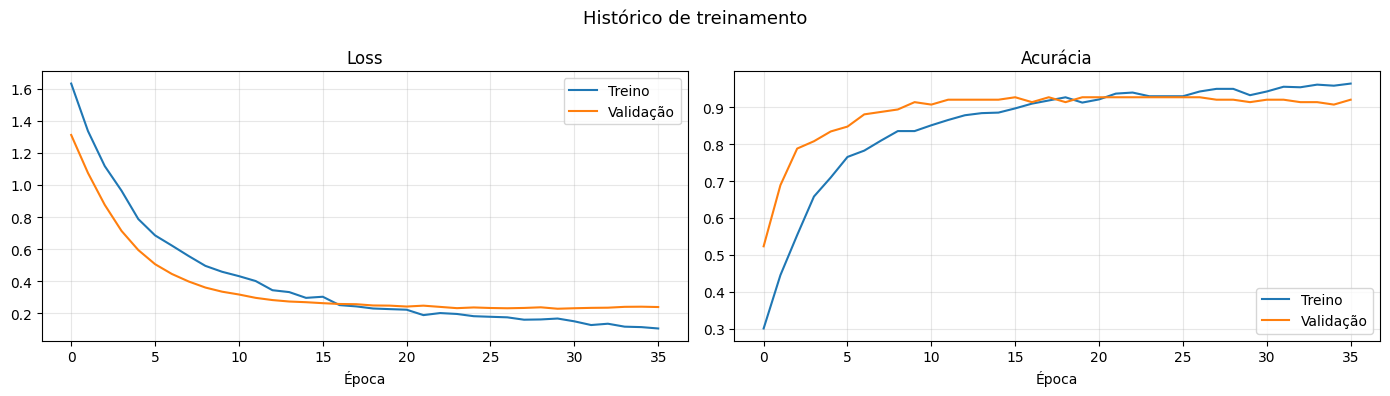

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(historico.history['loss'],     label='Treino')
ax1.plot(historico.history['val_loss'], label='Validação')
ax1.set_title('Loss'); ax1.set_xlabel('Época'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(historico.history['accuracy'],     label='Treino')
ax2.plot(historico.history['val_accuracy'], label='Validação')
ax2.set_title('Acurácia'); ax2.set_xlabel('Época'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Histórico de treinamento', fontsize=13); plt.tight_layout(); plt.show()

## 9. Avaliação no Conjunto de Teste

Acurácia (Keras): 0.8533  |  Loss: 0.3114



                      precision    recall  f1-score   support

              Normal       1.00      0.97      0.98        30
Desgaste Superficial       0.97      1.00      0.98        30
      Dente Trincado       0.75      0.80      0.77        30
       Dente Lascado       0.89      0.83      0.86        30
       Dente Ausente       0.67      0.67      0.67        30

            accuracy                           0.85       150
           macro avg       0.86      0.85      0.85       150
        weighted avg       0.86      0.85      0.85       150



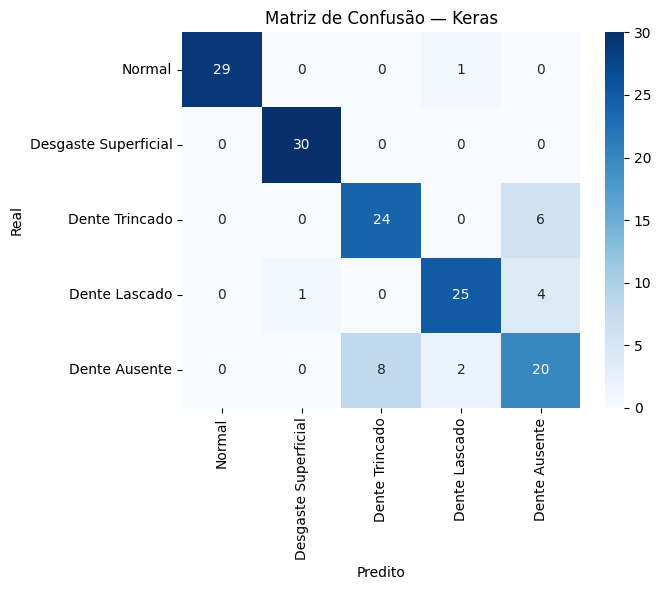

In [68]:
loss_test, acc_test = modelo.evaluate(X_test_n, y_test, verbose=0)
print(f'Acurácia (Keras): {acc_test:.4f}  |  Loss: {loss_test:.4f}\n')

y_pred = np.argmax(modelo.predict(X_test_n, verbose=0), axis=1)
print(classification_report(y_test, y_pred, target_names=nomes_classes_ordenados))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes_ordenados,
            yticklabels=nomes_classes_ordenados, ax=ax)
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Keras')
plt.tight_layout(); plt.show()

## 10. Conversão para TFLite Float32

In [69]:
converter_float = tf.lite.TFLiteConverter.from_keras_model(modelo)
tflite_float    = converter_float.convert()

caminho_float = MODEL_DIR / 'gearbox_float.tflite'
caminho_float.write_bytes(tflite_float)
print(f'Modelo float salvo: {caminho_float}  ({len(tflite_float)/1024:.1f} KB)')

Saved artifact at '/tmp/tmpo_jisrud'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 57), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  137411296098064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137411296093648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137411296095952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137411296093840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137411296095760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137411296094032: TensorSpec(shape=(), dtype=tf.resource, name=None)
Modelo float salvo: /content/gearbox_models/gearbox_float.tflite  (25.3 KB)


## 11. Quantização Int8 Completa

Entrada e saída em **int8** — requisito do TFLite Micro no ESP32. O dataset representativo (subset do treino normalizado) calibra os parâmetros de quantização.

In [70]:
def dataset_representativo():
    idx = np.random.default_rng(0).choice(len(X_train_n), size=500, replace=False)
    for i in idx:
        yield [X_train_n[i:i+1]]

saved_model_dir = str(MODEL_DIR / 'saved_model')
if hasattr(modelo, 'export'):
    modelo.export(saved_model_dir)
else:
    tf.saved_model.save(modelo, saved_model_dir)

converter_int8 = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
converter_int8.optimizations             = [tf.lite.Optimize.DEFAULT]
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type      = tf.int8
converter_int8.inference_output_type     = tf.int8
converter_int8.representative_dataset    = dataset_representativo

tflite_int8 = converter_int8.convert()

caminho_int8 = MODEL_DIR / 'gearbox_int8.tflite'
caminho_int8.write_bytes(tflite_int8)
print(f'Modelo int8 salvo: {caminho_int8}  ({len(tflite_int8)/1024:.1f} KB)')
print(f'Redução: {len(tflite_float)/len(tflite_int8):.2f}x menor')

Saved artifact at '/content/gearbox_models/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 57), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  137411296098064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137411296093648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137411296095952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137411296093840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137411296095760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137411296094032: TensorSpec(shape=(), dtype=tf.resource, name=None)
Modelo int8 salvo: /content/gearbox_models/gearbox_int8.tflite  (10.8 KB)
Redução: 2.34x menor


## 12. Validação dos Modelos TFLite

In [71]:
def avaliar_tflite(model_bytes: bytes, X: np.ndarray, y_true: np.ndarray, label: str):
    interpreter = tf.lite.Interpreter(model_content=model_bytes)
    interpreter.allocate_tensors()

    inp_det = interpreter.get_input_details()[0]
    out_det = interpreter.get_output_details()[0]
    in_scale,  in_zp  = inp_det.get('quantization', (1.0, 0))
    out_scale, out_zp = out_det.get('quantization', (1.0, 0))

    y_pred = []
    for x in X:
        sample = x.reshape(inp_det['shape']).astype(np.float32)
        if inp_det['dtype'] == np.int8:
            sample = np.clip(np.round(sample / in_scale + in_zp),
                             -128, 127).astype(np.int8)
        interpreter.set_tensor(inp_det['index'], sample)
        interpreter.invoke()
        out = interpreter.get_tensor(out_det['index'])[0]
        if out_det['dtype'] == np.int8:
            out = (out.astype(np.float32) - out_zp) * out_scale
        y_pred.append(np.argmax(out))

    y_pred = np.array(y_pred)
    acc    = float(np.mean(y_pred == y_true))
    print(f'\n=== {label} ===')
    print(f'Acurácia: {acc:.4f}')
    print(classification_report(y_true, y_pred, target_names=nomes_classes_ordenados))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=nomes_classes_ordenados,
                yticklabels=nomes_classes_ordenados, ax=ax)
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')
    ax.set_title(f'Matriz de Confusão — {label}')
    plt.tight_layout(); plt.show()
    return acc

print('Helpers TFLite definidos.')

Helpers TFLite definidos.


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



=== TFLite Float32 ===
Acurácia: 0.8533
                      precision    recall  f1-score   support

              Normal       1.00      0.97      0.98        30
Desgaste Superficial       0.97      1.00      0.98        30
      Dente Trincado       0.75      0.80      0.77        30
       Dente Lascado       0.89      0.83      0.86        30
       Dente Ausente       0.67      0.67      0.67        30

            accuracy                           0.85       150
           macro avg       0.86      0.85      0.85       150
        weighted avg       0.86      0.85      0.85       150



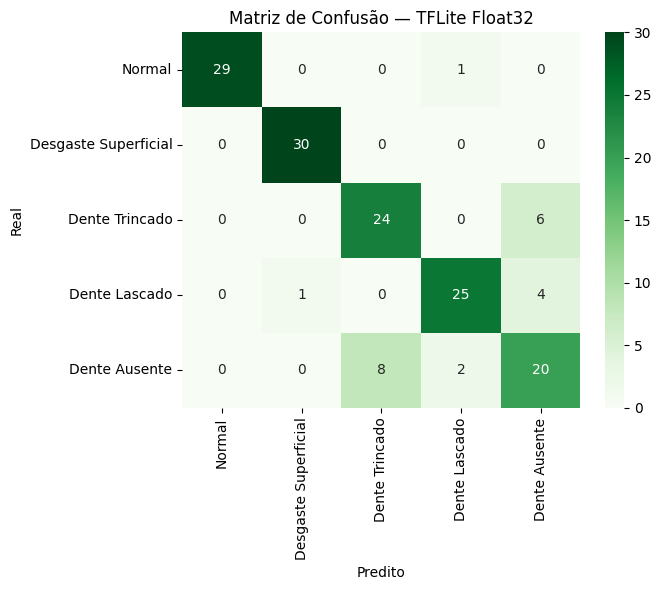

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



=== TFLite Int8 ===
Acurácia: 0.8600
                      precision    recall  f1-score   support

              Normal       1.00      0.97      0.98        30
Desgaste Superficial       0.97      1.00      0.98        30
      Dente Trincado       0.76      0.83      0.79        30
       Dente Lascado       0.89      0.83      0.86        30
       Dente Ausente       0.69      0.67      0.68        30

            accuracy                           0.86       150
           macro avg       0.86      0.86      0.86       150
        weighted avg       0.86      0.86      0.86       150



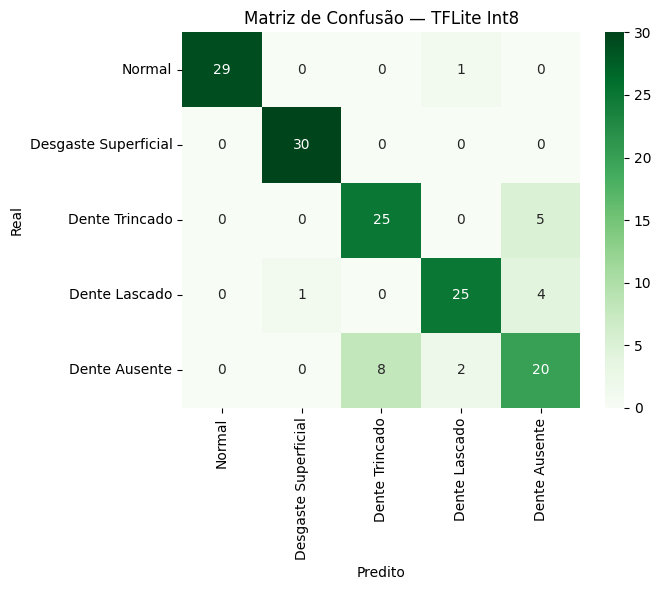


--- Resumo ---
Keras  Float32 : 0.8533
TFLite Float32 : 0.8533
TFLite Int8    : 0.8600
Delta Int8-Keras: +0.0067


In [72]:
acc_float = avaliar_tflite(tflite_float, X_test_n, y_test, 'TFLite Float32')
acc_int8  = avaliar_tflite(tflite_int8,  X_test_n, y_test, 'TFLite Int8')

print('\n--- Resumo ---')
print(f'Keras  Float32 : {acc_test:.4f}')
print(f'TFLite Float32 : {acc_float:.4f}')
print(f'TFLite Int8    : {acc_int8:.4f}')
print(f'Delta Int8-Keras: {acc_int8 - acc_test:+.4f}')

### 12b. Geração do `test_vectors.h` — validação bit-exata no ESP32

Exporta N amostras balanceadas (input int8 + output int8 do interpretador Python).  
No firmware, basta copiar `test_vectors[i].input` para `input->data.int8`, rodar `Invoke()` e comparar a saída byte-a-byte.

In [73]:
AMOSTRAS_POR_CLASSE = 4   # total = AMOSTRAS_POR_CLASSE * n_classes

# Roda o int8 e captura input/output para cada amostra escolhida
_rng = np.random.default_rng(123)
indices_por_classe = {
    c: _rng.choice(np.where(y_test == c)[0],
                   size=min(AMOSTRAS_POR_CLASSE, int((y_test == c).sum())),
                   replace=False)
    for c in range(n_classes)
}

interp = tf.lite.Interpreter(model_content=tflite_int8); interp.allocate_tensors()
inp_d = interp.get_input_details()[0]
out_d = interp.get_output_details()[0]
in_sc, in_zp_   = inp_d['quantization']
out_sc, out_zp_ = out_d['quantization']

vetores = []
for c in range(n_classes):
    for idx in indices_por_classe[c]:
        x_float = X_test_n[idx].astype(np.float32)
        x_q     = np.clip(np.round(x_float / in_sc + in_zp_), -128, 127).astype(np.int8)

        interp.set_tensor(inp_d['index'], x_q.reshape(inp_d['shape']))
        interp.invoke()
        y_int8 = interp.get_tensor(out_d['index'])[0].astype(np.int8)
        y_pred = int(np.argmax(y_int8))

        vetores.append({
            'true_class': c,
            'pred_class': y_pred,
            'input':      x_q,
            'output':     y_int8,
        })

def _fmt_int8_array(arr, indent='      '):
    partes = [f'{int(v):>4}' for v in arr]
    grupos = [indent + ', '.join(partes[i:i+8]) for i in range(0, len(partes), 8)]
    return ',\n'.join(grupos)

corpo_vetores = []
for i, v in enumerate(vetores):
    corpo_vetores.append(textwrap.dedent(f'''\
        {{  // [{i}] true={v["true_class"]} ({mapa_classes[v["true_class"]]})  pred={v["pred_class"]} ({mapa_classes[v["pred_class"]]})
          .input = {{
        {_fmt_int8_array(v["input"])}
          }},
          .expected_output = {{ {", ".join(f"{int(b):>4}" for b in v["output"])} }},
          .expected_class  = {v["pred_class"]},
          .true_class      = {v["true_class"]},
        }}'''))

corpo_vetores_str = ',\n'.join(corpo_vetores)

test_vectors_h = textwrap.dedent(f'''\
    // Auto-gerado pelo notebook — vetores de validação bit-exata.
    // Uso: para cada vetor, copie .input para input->data.int8 (size = INPUT_SIZE),
    // chame interpreter->Invoke() e compare output->data.int8 com .expected_output
    // byte-a-byte. Se todos baterem, a porta do modelo está correta.
    #ifndef TEST_VECTORS_H_
    #define TEST_VECTORS_H_

    #include <stdint.h>

    #define NUM_TEST_VECTORS {len(vetores)}
    #define TEST_INPUT_SIZE  {n_features}
    #define TEST_OUTPUT_SIZE {n_classes}

    // Parâmetros de quantização (devem bater com input/output do modelo carregado)
    #define TEST_INPUT_SCALE      {in_sc:.8f}f
    #define TEST_INPUT_ZERO_POINT {int(in_zp_)}
    #define TEST_OUTPUT_SCALE     {out_sc:.8f}f
    #define TEST_OUTPUT_ZERO_POINT {int(out_zp_)}

    typedef struct {{
      int8_t input[TEST_INPUT_SIZE];
      int8_t expected_output[TEST_OUTPUT_SIZE];
      int    expected_class;   // argmax(expected_output) — classe predita pelo TFLite Python
      int    true_class;       // rótulo real (ground truth)
    }} TestVector;

    const TestVector g_test_vectors[NUM_TEST_VECTORS] = {{
    {corpo_vetores_str}
    }};

    #endif  // TEST_VECTORS_H_
    ''')

(MODEL_DIR / 'test_vectors.h').write_text(test_vectors_h)

print(f'test_vectors.h gerado com {len(vetores)} amostras')
print(f'  - {AMOSTRAS_POR_CLASSE} por classe × {n_classes} classes')
print(f'  - tamanho do arquivo: {len(test_vectors_h)/1024:.1f} KB')
print(f'\nDistribuição true/pred:')
for v in vetores:
    ok = '✓' if v['true_class'] == v['pred_class'] else '✗'
    print(f'  {ok} true={v["true_class"]} pred={v["pred_class"]}')
print('\nPreview:')
print(test_vectors_h[:600], '...')

test_vectors.h gerado com 20 amostras
  - 4 por classe × 5 classes
  - tamanho do arquivo: 11.7 KB

Distribuição true/pred:
  ✓ true=0 pred=0
  ✓ true=0 pred=0
  ✓ true=0 pred=0
  ✗ true=0 pred=3
  ✓ true=1 pred=1
  ✓ true=1 pred=1
  ✓ true=1 pred=1
  ✓ true=1 pred=1
  ✓ true=2 pred=2
  ✓ true=2 pred=2
  ✓ true=2 pred=2
  ✓ true=2 pred=2
  ✓ true=3 pred=3
  ✓ true=3 pred=3
  ✓ true=3 pred=3
  ✓ true=3 pred=3
  ✗ true=4 pred=2
  ✓ true=4 pred=4
  ✗ true=4 pred=2
  ✓ true=4 pred=4

Preview:
    // Auto-gerado pelo notebook — vetores de validação bit-exata.
    // Uso: para cada vetor, copie .input para input->data.int8 (size = INPUT_SIZE),
    // chame interpreter->Invoke() e compare output->data.int8 com .expected_output
    // byte-a-byte. Se todos baterem, a porta do modelo está correta.
    #ifndef TEST_VECTORS_H_
    #define TEST_VECTORS_H_

    #include <stdint.h>

    #define NUM_TEST_VECTORS 20
    #define TEST_INPUT_SIZE  57
    #define TEST_OUTPUT_SIZE 5

    // Parâmetros de q

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 13. Geração dos Arquivos para o ESP32

### 13a. `model.cc` — array C do modelo int8

In [74]:
def bytes_para_c_array(data: bytes, guard: str = 'MODEL_H_') -> str:
    linhas = []
    for i in range(0, len(data), 12):
        chunk = data[i:i+12]
        linhas.append('  ' + ', '.join(f'0x{b:02x}' for b in chunk) + ',')
    corpo = '\n'.join(linhas).rstrip(',')
    return textwrap.dedent(f'''\
        // Auto-gerado pelo notebook de treinamento — não editar manualmente.
        #ifndef {guard}
        #define {guard}

        #include "model.h"

        alignas(8) const unsigned char g_model[] = {{
        {corpo}
        }};
        const int g_model_len = {len(data)};

        #endif  // {guard}
        ''')

conteudo_model_cc = bytes_para_c_array(tflite_int8)
(MODEL_DIR / 'model.cc').write_text(conteudo_model_cc)
print(f'model.cc gerado ({len(tflite_int8)} bytes de modelo)')
print(conteudo_model_cc[:400], '...')

model.cc gerado (11088 bytes de modelo)
      // Auto-gerado pelo notebook de treinamento — não editar manualmente.
      #ifndef MODEL_H_
      #define MODEL_H_

      #include "model.h"

      alignas(8) const unsigned char g_model[] = {
        0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00,
0x14, 0x00, 0x20, 0x00, 0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00,
0x0c, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00,  ...


### 13b. `scaler_params.h` — parâmetros de normalização e metadados do modelo

In [75]:
def array_c_float(nome: str, valores: np.ndarray) -> str:
    partes = [f'{v:.8f}f' for v in valores]
    grupos = ['    ' + ', '.join(partes[i:i+4]) + ',' for i in range(0, len(partes), 4)]
    corpo  = '\n'.join(grupos).rstrip(',')
    return f'const float {nome}[{len(valores)}] = {{\n{corpo}\n}};'

# Lê parâmetros de quantização do modelo int8
_interp = tf.lite.Interpreter(model_content=tflite_int8); _interp.allocate_tensors()
_inp = _interp.get_input_details()[0]
_out = _interp.get_output_details()[0]
in_scale,  in_zp  = _inp['quantization']
out_scale, out_zp = _out['quantization']

lista_features = '\n'.join(f'// [{i:>2}] {n}' for i, n in enumerate(colunas_features))

scaler_h = textwrap.dedent(f'''\
    // Auto-gerado pelo notebook de treinamento.
    // 1) Calcule as {n_features} features na mesma ordem de FEATURE_NAMES.
    // 2) Normalize:  norm[i] = (feat[i] - SCALER_MEAN[i]) / SCALER_SCALE[i]
    // 3) Quantize:   q[i]    = round(norm[i] / INPUT_SCALE + INPUT_ZERO_POINT)  [clip em -128..127]
    // 4) Copie q[] para input->data.int8[].
    // 5) Após Invoke(), output->data.int8[k] -> probabilidade ~= (out_k - OUTPUT_ZERO_POINT)*OUTPUT_SCALE
    #ifndef SCALER_PARAMS_H_
    #define SCALER_PARAMS_H_

    #define N_FEATURES {n_features}
    #define N_CLASSES  {n_classes}

    // ---- Quantização da entrada (int8) ----
    const float INPUT_SCALE       = {in_scale:.8f}f;
    const int   INPUT_ZERO_POINT  = {int(in_zp)};

    // ---- Quantização da saída (int8) ----
    const float OUTPUT_SCALE      = {out_scale:.8f}f;
    const int   OUTPUT_ZERO_POINT = {int(out_zp)};

    // ---- Frequências cinemáticas usadas na extração de features ----
    const float FS_HZ             = {float(fs):.4f}f;
    const int   AMOSTRAS_POR_SEG  = {amostras_por_intervalo};
    const float FM1_TEORICO_HZ    = {Fm1:.6f}f;
    const float FM2_TEORICO_HZ    = {Fm2:.6f}f;
    const float FCSD1_HZ          = {Fcsd1:.6f}f;
    const float FCSD2_HZ          = {Fcsd2:.6f}f;
    const float FCSL1_HZ          = {Fcsl1:.6f}f;
    const float FCSL2_HZ          = {Fcsl2:.6f}f;
    const float LARGURA_BUSCA_FM_HZ      = {largura_busca_fm_real_hz:.4f}f;
    const float LARGURA_BANDA_HARM_HZ    = {largura_banda_harmonica_hz:.4f}f;

    // ---- Ordem das features (use exatamente esta ordem ao montar o vetor) ----
    {lista_features}

    {array_c_float('SCALER_MEAN',  scaler.mean_)}

    {array_c_float('SCALER_SCALE', scaler.scale_)}

    // Saída do modelo (índice = classe):
    // 0: Normal | 1: Desgaste Superficial | 2: Dente Trincado
    // 3: Dente Lascado | 4: Dente Ausente

    #endif  // SCALER_PARAMS_H_
    ''')

(MODEL_DIR / 'scaler_params.h').write_text(scaler_h)
print(f'scaler_params.h gerado ({n_features} features)')
print(scaler_h[:700], '...')

scaler_params.h gerado (57 features)
    // Auto-gerado pelo notebook de treinamento.
    // 1) Calcule as 57 features na mesma ordem de FEATURE_NAMES.
    // 2) Normalize:  norm[i] = (feat[i] - SCALER_MEAN[i]) / SCALER_SCALE[i]
    // 3) Quantize:   q[i]    = round(norm[i] / INPUT_SCALE + INPUT_ZERO_POINT)  [clip em -128..127]
    // 4) Copie q[] para input->data.int8[].
    // 5) Após Invoke(), output->data.int8[k] -> probabilidade ~= (out_k - OUTPUT_ZERO_POINT)*OUTPUT_SCALE
    #ifndef SCALER_PARAMS_H_
    #define SCALER_PARAMS_H_

    #define N_FEATURES 57
    #define N_CLASSES  5

    // ---- Quantização da entrada (int8) ----
    const float INPUT_SCALE       = 0.05156828f;
    const int   INPUT_ZERO_POINT  = -82;

    // ...


### 13c. Resumo para integração com `main_functions.cc`

In [76]:
print('=== Modelo int8 — informações para o firmware ===')
print(f'  Input  : int8[{n_features}]   scale={in_scale:.6f}  zp={int(in_zp)}')
print(f'  Output : int8[{n_classes}]   scale={out_scale:.6f}  zp={int(out_zp)}')
print(f'  Tamanho do .tflite : {len(tflite_int8)} bytes  ({len(tflite_int8)/1024:.1f} KB)')
print(f'  kTensorArenaSize sugerido : {max(4096, len(tflite_int8)*2)} bytes')
print()
print('--- No main_functions.cc, manter: ---')
print('   static tflite::MicroMutableOpResolver<1> resolver;')
print('   resolver.AddFullyConnected();')
print()
print('--- Fluxo de inferência (pseudo-código C) ---')
print('  1) Adquirir ~10000 amostras (1 s) de cada eixo X,Y,Z @ 10 kHz')
print('  2) Calcular as 45 features na ordem de FEATURE_NAMES (scaler_params.h)')
print('  3) Normalizar com SCALER_MEAN / SCALER_SCALE')
print('  4) Quantizar com INPUT_SCALE / INPUT_ZERO_POINT')
print('  5) Invoke() — argmax do output->data.int8[] dá a classe predita')

=== Modelo int8 — informações para o firmware ===
  Input  : int8[57]   scale=0.051568  zp=-82
  Output : int8[5]   scale=0.003906  zp=-128
  Tamanho do .tflite : 11088 bytes  (10.8 KB)
  kTensorArenaSize sugerido : 22176 bytes

--- No main_functions.cc, manter: ---
   static tflite::MicroMutableOpResolver<1> resolver;
   resolver.AddFullyConnected();

--- Fluxo de inferência (pseudo-código C) ---
  1) Adquirir ~10000 amostras (1 s) de cada eixo X,Y,Z @ 10 kHz
  2) Calcular as 45 features na ordem de FEATURE_NAMES (scaler_params.h)
  3) Normalizar com SCALER_MEAN / SCALER_SCALE
  4) Quantizar com INPUT_SCALE / INPUT_ZERO_POINT
  5) Invoke() — argmax do output->data.int8[] dá a classe predita


## 14. Download dos Artefatos (Colab)

In [77]:
if IS_COLAB:
    from google.colab import files
    for nome in ['gearbox_int8.tflite', 'gearbox_float.tflite',
                 'model.cc', 'scaler_params.h', 'test_vectors.h']:
        p = MODEL_DIR / nome
        if p.exists():
            files.download(str(p))
            print(f'Download: {nome}')
else:
    print('Não está no Colab — arquivos em:', MODEL_DIR.resolve())
    for f in MODEL_DIR.iterdir():
        print(f'  {f.name}  ({f.stat().st_size} bytes)')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download: gearbox_int8.tflite


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Download: scaler_params.h


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download: test_vectors.h
